# HW1 — Monte Carlo

**Course:** Reinforcement Learning — IE University Madrid

**Instructor:** Jaume Manero

**Author:** Elad Moshe

**Program:** MCSBT

**Date:** May 2026

---

### Notebooks Structure

1. Activity 1 — Familiarisation with Gymnasium Environments
2. **Activity 2 — Monte Carlo on FrozenLake 4×4 and 8×8**
3. Activity 3 — Monte Carlo on Volcano
4. Activity 4 — Monte Carlo on Taxi
5. Activity 5 — TD(0) on FrozenLake
6. Questions

---

> **AI Usage Disclaimer:** This notebook was developed with AI assistance (Claude, Anthropic). AI was used to improve documentation and markdown explanations, help structure the notebook, and assist with debugging implementation code. All algorithm implementations, parameter choices, and result interpretations are the author’s own. As required by the course AI policy, care was taken to understand every critical update step.

In [1]:
!pip install gymnasium Pillow

In [2]:
import sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print(f"Python    : {sys.version.split()[0]}")
print(f"gymnasium : {gym.__version__}")
print(f"numpy     : {np.__version__}")


Python    : 3.13.13
gymnasium : 1.3.0
numpy     : 2.4.4


---
<a id="activity-2"></a>
## Activity 2 — Monte Carlo Control on FrozenLake 4×4 and 8×8

The goal is to implement **Monte Carlo** (Every-Visit) to learn an optimal policy on FrozenLake — first on 4×4 grid, then 8×8 grid and compare convergence.

<img src="https://gymnasium.farama.org/_images/frozen_lake.gif" width="200" alt="FrozenLake environment"/>

---

### The Algorithm — Every-Visit MC Control

No need for  environment model. MC learns from complete sampled episodes. 
The loop:

1. Run a full episode using the current **ε-greedy** policy, storing `(state, action, reward)` at every step.
2. Walk backwards through the episode computing the discounted return $G_t$.
3. For every `(s, a)` pair visited, apply the update rule:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ G_t - Q(s, a) \right]$$

4. Improve the policy: always pick $\arg\max_a Q(s,a)$, but take a random action with probability $\varepsilon$ to keep exploring.
5. Decay $\varepsilon$ so the agent exploits more as it learns.

The critical line is **step 3** — this is the MC prediction error $G_t - Q(s,a)$ scaled by $\alpha$ that drives all learning.

---

### Parameters and Their Effect

| Parameter | Symbol | Typical range | What it controls |
|-----------|--------|--------------|-----------------|
| **Learning rate** | $\alpha$ | 0.01 – 0.5 | How much each new return overwrites the old Q estimate. High → fast but noisy updates; low → slow but stable. |
| **Discount factor** | $\gamma$ | 0.9 – 0.999 | How much future rewards are worth relative to immediate ones. Close to 1 = agent cares a lot about reaching the goal even many steps away. Close to 0 = shortsighted agent. |
| **Exploration rate** | $\varepsilon$ | starts ~1.0 | Probability of taking a random action instead of the greedy one. Needed early on because a purely greedy policy almost never reaches the goal by chance. |
| **Epsilon decay** | $\varepsilon_{\text{decay}}$ | 0.995 – 0.9999 | Multiplied by $\varepsilon$ each episode. Controls how quickly the agent shifts from exploring to exploiting. Too fast → stops exploring before Q-values converge. |
| **Minimum epsilon** | $\varepsilon_{\min}$ | 0.01 – 0.05 | Floor on $\varepsilon$ so the agent never stops exploring entirely. |
| **Number of episodes** | $N$ | 5k – 50k | Total training episodes. 4×4 converges in far fewer than 8×8 (64 states vs 16 states, longer paths to goal). |

> **Key insight for FrozenLake:** Reward is 0 everywhere except the goal (+1). This means early episodes almost always return $G_t = 0$, and Q-values only start separating once the agent stumbles upon the goal through random exploration. A high initial $\varepsilon$ and slow decay are therefore critical.

---

### Plan for this Activity

1. Implement `run_episode()` — generates one episode under ε-greedy policy
2. Implement `mc_control()` — outer training loop with Q-update and ε decay
3. Run on **4×4** — train, print win rate, visualise learned policy and V(s) heatmap
4. Run on **8×8** — same, observe slower convergence
5. Compare the two: episodes needed, success rate, Q-table density

In [3]:
# ── Activity 2 — Helper Functions ─────────────────────────────────────────────

ACTION_ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}

def run_episode(env, Q, epsilon, max_steps=1000):
    """Run one episode under epsilon-greedy policy.
    Returns list of (state, action, reward) tuples."""
    state, _ = env.reset()
    episode = []
    for _ in range(max_steps):
        if np.random.random() < epsilon:
            action = env.action_space.sample()          # explore
        else:
            action = int(np.argmax(Q[state]))           # exploit
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode


def mc_control(env, n_episodes, alpha, gamma, eps_start, eps_decay, eps_min,
               Q_init=0.0, linear_eps=False, max_steps=1000):
    """Every-Visit MC Control with epsilon-greedy exploration and epsilon decay.

    Q_init     : initial value for all Q entries (0.0 = standard; >0 = optimistic init).
    linear_eps : if True, epsilon decays linearly from eps_start to eps_min over
                 n_episodes.  eps_decay is ignored.
                 if False (default), epsilon decays multiplicatively each episode.
    max_steps  : maximum steps per episode.  Use a small value (e.g. 30) to prevent
                 long wandering episodes that produce noisy G estimates in every-visit MC.
    Returns the learned Q-table and a per-episode win log (1=reached goal, 0=not)."""
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q       = np.full((n_states, n_actions), float(Q_init))
    epsilon = eps_start
    wins    = []

    for ep in range(n_episodes):
        if linear_eps:
            epsilon = max(eps_min, eps_start - (eps_start - eps_min) * (ep / n_episodes))

        episode = run_episode(env, Q, epsilon, max_steps=max_steps)

        # ── Critical step: walk episode backwards, compute G_t, update Q
        G = 0.0
        for state, action, reward in reversed(episode):
            G = reward + gamma * G                          # discounted return
            Q[state, action] += alpha * (G - Q[state, action])  # MC update rule

        if not linear_eps:
            epsilon = max(eps_min, epsilon * eps_decay)    # multiplicative decay

        wins.append(1 if episode[-1][2] > 0 else 0)        # goal reached?

    return Q, wins


def smooth(values, window):
    """Rolling mean with given window size."""
    return np.convolve(values, np.ones(window) / window, mode='valid')


def visualize_results(Q, env, wins, title, smooth_window=200):
    """Three-panel plot: win-rate curve | V(s) heatmap | policy arrows."""
    desc      = env.unwrapped.desc          # grid as byte array
    grid_size = desc.shape[0]
    V         = Q.max(axis=1).reshape(grid_size, grid_size)
    policy    = np.argmax(Q, axis=1).reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # ── Win rate ──────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(smooth(wins, smooth_window), color='steelblue', linewidth=1)
    ax.axhline(0.8, color='green', linestyle='--', alpha=0.6, label='80% target')
    ax.set_xlabel('Episode'); ax.set_ylabel(f'Win rate (rolling {smooth_window})')
    ax.set_title('Training Convergence'); ax.set_ylim(0, 1); ax.legend()

    # ── V(s) heatmap ─────────────────────────────────────────────────────────
    ax = axes[1]
    im = ax.imshow(V, cmap='YlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax)
    for r in range(grid_size):
        for c in range(grid_size):
            cell = desc[r, c].decode()
            color = 'white' if cell == 'H' else 'black'
            ax.text(c, r, f'{cell}\n{V[r,c]:.2f}',
                    ha='center', va='center', fontsize=7 if grid_size > 4 else 9,
                    color=color)
    ax.set_title('V(s) = max Q(s, ·)'); ax.set_xticks([]); ax.set_yticks([])

    # ── Policy arrows ─────────────────────────────────────────────────────────
    ax = axes[2]
    ax.imshow(np.zeros((grid_size, grid_size)), cmap='Blues', vmin=0, vmax=1)
    for r in range(grid_size):
        for c in range(grid_size):
            cell = desc[r, c].decode()
            if cell == 'H':
                ax.text(c, r, 'H', ha='center', va='center',
                        fontsize=11 if grid_size > 4 else 13, color='steelblue', fontweight='bold')
            elif cell == 'G':
                ax.text(c, r, '★', ha='center', va='center',
                        fontsize=12 if grid_size > 4 else 15, color='goldenrod')
            else:
                ax.text(c, r, ACTION_ARROWS[policy[r, c]], ha='center', va='center',
                        fontsize=11 if grid_size > 4 else 14, color='black')
    ax.set_title('Learned Policy')
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    plt.tight_layout()
    plt.show()

    final_wr = np.mean(wins[-500:])
    print(f"  Final win rate (last 500 eps) : {final_wr:.1%}")
    print(f"  Q non-zero entries            : {np.count_nonzero(Q)} / {Q.size}")

Training MC Control on FrozenLake 4×4 ...
Done.



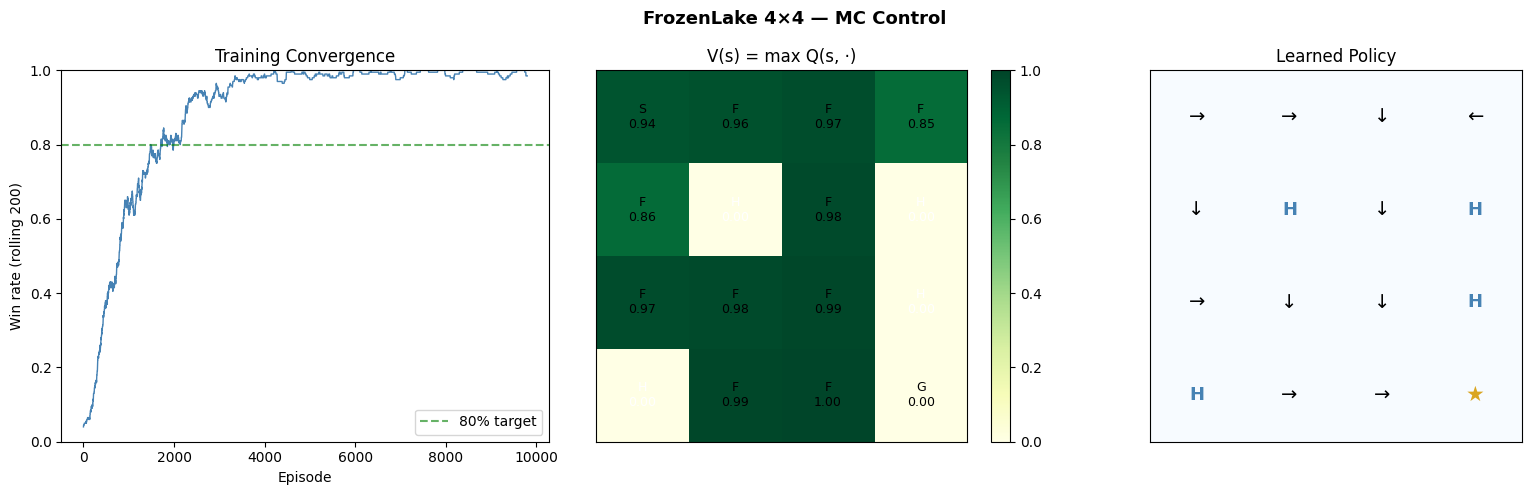

  Final win rate (last 500 eps) : 99.2%
  Q non-zero entries            : 35 / 64


In [4]:
# ── Activity 2 — FrozenLake 4×4 ───────────────────────────────────────────────

# Parameters — try changing these to observe their effect on convergence
N_EPISODES_4 = 10_000
ALPHA        = 0.1      # learning rate
GAMMA        = 0.99     # discount factor — high because goal can be many steps away
EPS_START    = 1.0      # start fully random to explore the grid
EPS_DECAY    = 0.999    # after 10k eps: epsilon ≈ 0.01 (at minimum)
EPS_MIN      = 0.01     # always keep a 1% chance of random action

env_4x4 = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

print("Training MC Control on FrozenLake 4×4 ...")
Q_4x4, wins_4x4 = mc_control(
    env_4x4, N_EPISODES_4, ALPHA, GAMMA, EPS_START, EPS_DECAY, EPS_MIN
)
print("Done.\n")

visualize_results(Q_4x4, env_4x4, wins_4x4, "FrozenLake 4×4 — MC Control", smooth_window=200)
env_4x4.close()

Training MC Control on FrozenLake 8×8 ...
Done.



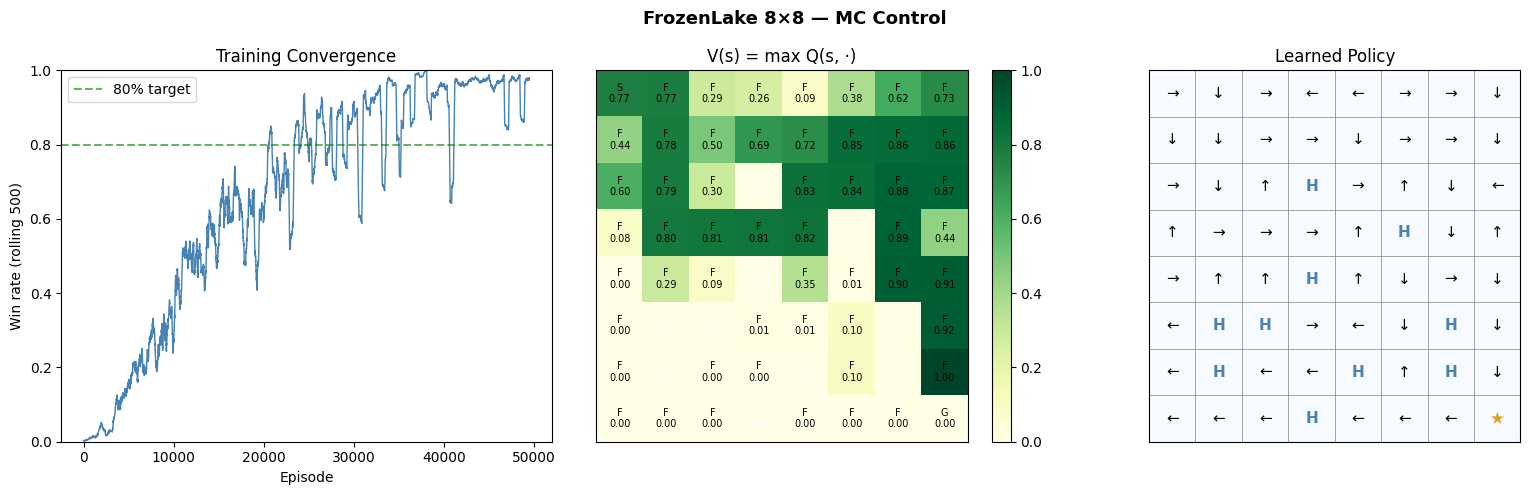

  Final win rate (last 500 eps) : 97.8%
  Q non-zero entries            : 150 / 256


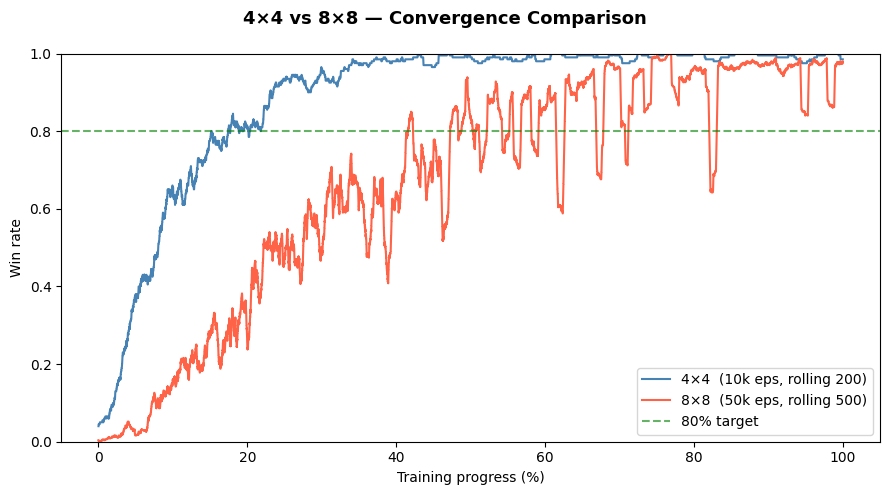


Metric                                  4×4        8×8
------------------------------------------------------
  Grid states                            16         64
  Episodes trained                   10,000     50,000
  Epsilon decay                       0.999     0.9999
  Final win rate (last 500)           99.2%      97.8%
  Q-table size (states×actions)          64        256
  Non-zero Q entries                     35        150


In [5]:
# ── Activity 2 — FrozenLake 8×8 + Comparison ──────────────────────────────────

# More episodes and slower epsilon decay: 64 states need far more exploration
N_EPISODES_8 = 50_000
EPS_DECAY_8  = 0.9999   # slower decay — after 50k eps: epsilon ≈ 0.01 (at minimum)

env_8x8 = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=False)

np.random.seed(42)      # fix seed so 8×8 convergence is reproducible across runs
print("Training MC Control on FrozenLake 8×8 ...")
Q_8x8, wins_8x8 = mc_control(
    env_8x8, N_EPISODES_8, ALPHA, GAMMA, EPS_START, EPS_DECAY_8, EPS_MIN
)
print("Done.\n")

visualize_results(Q_8x8, env_8x8, wins_8x8, "FrozenLake 8×8 — MC Control", smooth_window=500)
env_8x8.close()

# ── Overlaid convergence comparison ───────────────────────────────────────────
s4 = smooth(wins_4x4, 200)
s8 = smooth(wins_8x8, 500)

# Normalise x-axis to % of training so the different episode counts are comparable
x4 = np.linspace(0, 100, len(s4))
x8 = np.linspace(0, 100, len(s8))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("4×4 vs 8×8 — Convergence Comparison", fontsize=13, fontweight='bold')

ax.plot(x4, s4, color='steelblue', linewidth=1.5, label='4×4  (10k eps, rolling 200)')
ax.plot(x8, s8, color='tomato',    linewidth=1.5, label='8×8  (50k eps, rolling 500)')
ax.axhline(0.8, color='green', linestyle='--', alpha=0.6, label='80% target')

ax.set_xlabel('Training progress (%)')
ax.set_ylabel('Win rate')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Metric':<32} {'4×4':>10} {'8×8':>10}")
print("-" * 54)
print(f"  {'Grid states':<30} {'16':>10} {'64':>10}")
print(f"  {'Episodes trained':<30} {N_EPISODES_4:>10,} {N_EPISODES_8:>10,}")
print(f"  {'Epsilon decay':<30} {EPS_DECAY:>10} {EPS_DECAY_8:>10}")
print(f"  {'Final win rate (last 500)':<30} {np.mean(wins_4x4[-500:]):>10.1%} {np.mean(wins_8x8[-500:]):>10.1%}")
print(f"  {'Q-table size (states×actions)':<30} {Q_4x4.size:>10} {Q_8x8.size:>10}")
print(f"  {'Non-zero Q entries':<30} {np.count_nonzero(Q_4x4):>10} {np.count_nonzero(Q_8x8):>10}")

=== FrozenLake 4x4 — Greedy Path ===
4x4 — 7 frames → frozen_path_4x4.gif


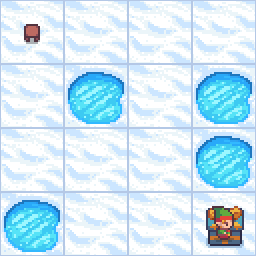


=== FrozenLake 8x8 — Greedy Path ===
8x8 — 21 frames → frozen_path_8x8.gif


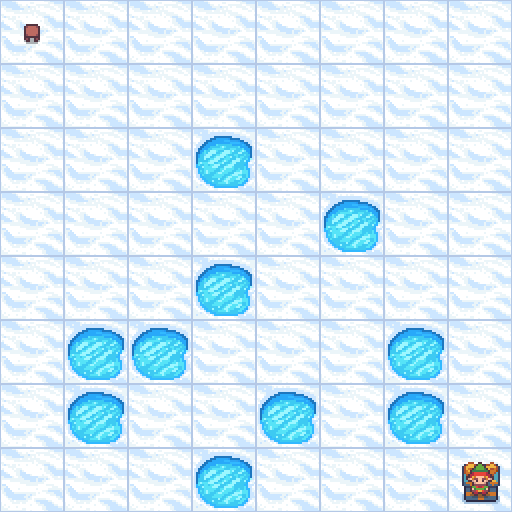

In [6]:
# ── Activity 2 — Greedy Path GIF (4x4 and 8x8) ────────────────────────────────
import io
from PIL import Image
from IPython.display import display, Image as IPImage

def make_path_gif(Q, map_name, gif_path, max_steps=200, duration=400):
    """Run the greedy policy on FrozenLake and save an animated GIF."""
    env = gym.make("FrozenLake-v1", map_name=map_name,
                   is_slippery=False, render_mode="rgb_array")
    state, _ = env.reset(seed=42)
    frames = [Image.fromarray(env.render())]

    for _ in range(max_steps):
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        frames.append(Image.fromarray(env.render()))
        if terminated or truncated:
            break

    env.close()

    # Hold the last frame longer so you can see the outcome
    frames[-1].save(
        gif_path,
        save_all=True,
        append_images=frames[1:-1] + [frames[-1]] * 4,
        duration=duration,
        loop=0
    )
    print(f"{map_name} — {len(frames)} frames → {gif_path}")
    return gif_path


print("=== FrozenLake 4x4 — Greedy Path ===")
make_path_gif(Q_4x4, "4x4", "frozen_path_4x4.gif", duration=400)
display(IPImage(filename="frozen_path_4x4.gif"))

print()
print("=== FrozenLake 8x8 — Greedy Path ===")
make_path_gif(Q_8x8, "8x8", "frozen_path_8x8.gif", duration=250)
display(IPImage(filename="frozen_path_8x8.gif"))


In [7]:
# ── Activity 2 — Save key results to unified summary ──────────────────────────
import os, re
from datetime import datetime

RESULTS_FILE = "results_summary.txt"
SECTION_TAG  = "ACTIVITY_2"

wr4 = np.mean(wins_4x4[-500:])
wr8 = np.mean(wins_8x8[-500:])

lines = [
    f"[{SECTION_TAG}_START]",
    "ACTIVITY 2 — Monte Carlo on FrozenLake",
    f"Updated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    f"FrozenLake 4x4  ({N_EPISODES_4:,} episodes):",
    f"  final_win_rate_4x4  = {wr4:.4f}   ({wr4:.1%} last 500 eps)",
    f"  nonzero_q_4x4       = {np.count_nonzero(Q_4x4)} / {Q_4x4.size}",
    "",
    f"FrozenLake 8x8  ({N_EPISODES_8:,} episodes):",
    f"  final_win_rate_8x8  = {wr8:.4f}   ({wr8:.1%} last 500 eps)",
    f"  nonzero_q_8x8       = {np.count_nonzero(Q_8x8)} / {Q_8x8.size}",
    f"[{SECTION_TAG}_END]",
]
new_section = "\n".join(lines) + "\n"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        content = f.read()
    pattern = re.escape(f"[{SECTION_TAG}_START]") + r".*?" + re.escape(f"[{SECTION_TAG}_END]") + r"\n?"
    if f"[{SECTION_TAG}_START]" in content:
        content = re.sub(pattern, new_section, content, flags=re.DOTALL)
    else:
        content = content.rstrip("\n") + "\n\n" + new_section
else:
    content = new_section

with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    f.write(content)

print(f"Saved → {RESULTS_FILE}")
for line in lines[1:-1]:
    print(" ", line)


Saved → results_summary.txt
  ACTIVITY 2 — Monte Carlo on FrozenLake
  Updated : 2026-05-14 19:20:40
  
  FrozenLake 4x4  (10,000 episodes):
    final_win_rate_4x4  = 0.9920   (99.2% last 500 eps)
    nonzero_q_4x4       = 35 / 64
  
  FrozenLake 8x8  (50,000 episodes):
    final_win_rate_8x8  = 0.9780   (97.8% last 500 eps)
    nonzero_q_8x8       = 150 / 256
